# Detección de Fraude en Transacciones de Tarjeta de Crédito
## Caso de Uso de Clasificación — CRISP-DM
**Universidad Popular del Cesar**

Docente: Aimer Rivera Centeno

In [8]:
# ============================================================
# CELDA 2: IMPORTS — Todas las librerías necesarias
# ============================================================
# Importamos pandas para manipulación de datos tabulares
import pandas as pd
# NumPy para operaciones numéricas y manejo de arreglos
import numpy as np
# Matplotlib y Seaborn para visualizaciones estáticas
import matplotlib.pyplot as plt
import seaborn as sns
# Plotly para visualizaciones interactivas (dashboard y notebook)
import plotly.express as px
import plotly.graph_objects as go
# Suprimimos warnings para que el notebook se vea limpio
import warnings
warnings.filterwarnings('ignore')

# === SKLEARN: Modelado, preprocesamiento y métricas ===
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, precision_score, recall_score)

# === IMBALANCED-LEARN: SMOTE para manejo de desbalance ===
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# === XGBOOST: Gradient boosting optimizado ===
import xgboost as xgb

# === JOBLIB: Para guardar y cargar modelos ===
import joblib
import os

## Fase 1: Comprensión del Negocio

**Objetivo del negocio:** Minimizar pérdidas financieras detectando transacciones fraudulentas de tarjetas de crédito.

**Problema:** Clasificación binaria supervisada — dada una transacción con 30 características (V1-V28, Time, Amount), predecir si es fraude (1) o legítima (0).

**Métrica principal:** Recall de la clase fraude. Un falso negativo (fraude no detectado) implica pérdida económica directa. Priorizamos capturar la mayor cantidad de fraudes posible, incluso si esto genera algunos falsos positivos.

## Fase 2: Comprensión de los Datos

In [9]:
# ============================================================
# CELDA 4: CARGA DE DATOS Y EDA BÁSICO
# ============================================================
# Cargamos el dataset de transacciones con tarjeta de crédito
# El dataset debe estar en la carpeta 'data/' del proyecto
df = pd.read_csv('../data/creditcard.csv')

# Mostramos dimensiones del dataset: 284,807 transacciones x 31 columnas
print("Shape:", df.shape)

# Vista rápida de las primeras 5 filas para entender la estructura
print("\nPrimeras filas:")
display(df.head())

# Información detallada: tipos de datos, memoria usada, valores no nulos
print("\nInformación del dataset:")
df.info()

# Estadísticas descriptivas básicas (media, std, min, max, cuartiles)
print("\nEstadísticas descriptivas:")
display(df.describe())

# Verificamos valores nulos — el dataset debe estar limpio
print("\nValores nulos:")
print(df.isnull().sum())

Shape: (284807, 31)

Primeras filas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Valores nulos:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [10]:
# ============================================================
# CELDA 5: DISTRIBUCIÓN DE CLASES (Gráfico Pie Interactivo)
# ============================================================
# Calculamos la frecuencia de cada clase
# 0 = Legítima, 1 = Fraude
clase_counts = df['Class'].value_counts()

# Gráfico de pastel interactivo con Plotly
# Usamos azul para legítima y rojo para fraude (código de colores intuitivo)
fig = px.pie(values=clase_counts.values,
             names=['Legítima (0)', 'Fraude (1)'],
             title='Distribución de Clases — Dataset Extremadamente Desbalanceado',
             color_discrete_sequence=['#2196F3', '#F44336'])
fig.show()

# Imprimimos los valores exactos para sustentación
print(f"\nTransacciones legítimas: {clase_counts[0]:,} ({clase_counts[0]/len(df)*100:.2f}%)")
print(f"Transacciones fraudulentas: {clase_counts[1]:,} ({clase_counts[1]/len(df)*100:.4f}%)")


Transacciones legítimas: 284,315 (99.83%)
Transacciones fraudulentas: 492 (0.1727%)


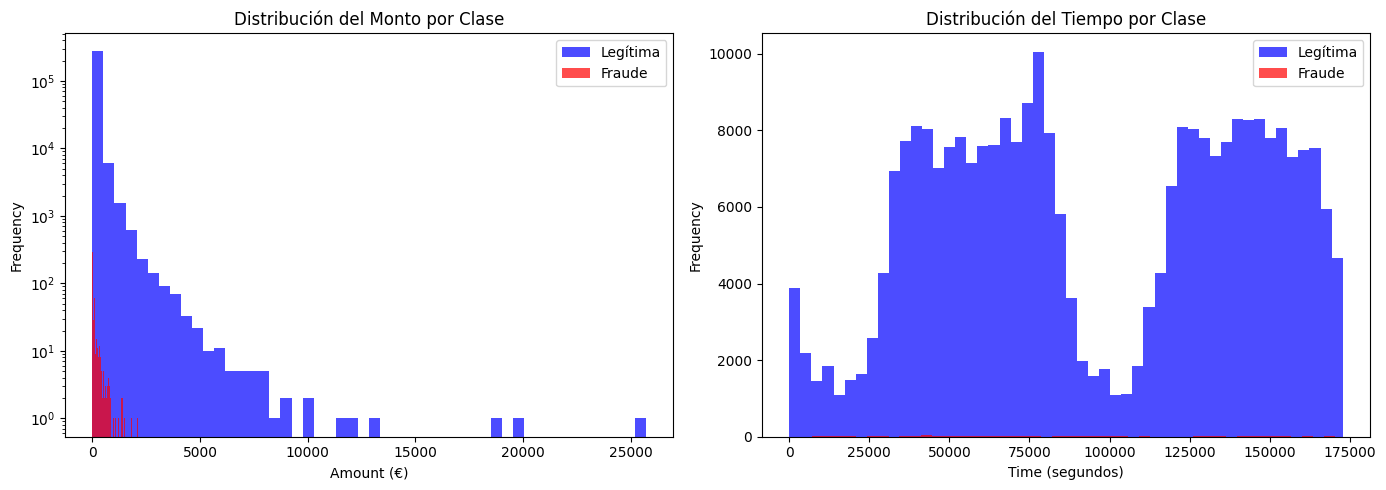

In [11]:
# ============================================================
# CELDA 6: DISTRIBUCIÓN DE AMOUNT Y TIME POR CLASE
# ============================================================
# Comparamos cómo se distribuyen el monto y el tiempo
# para transacciones legítimas vs fraudulentas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Amount por clase ===
# Histograma del monto (Amount) separado por clase
df[df['Class']==0]['Amount'].plot(kind='hist', bins=50, ax=axes[0],
    alpha=0.7, color='blue', label='Legítima')
df[df['Class']==1]['Amount'].plot(kind='hist', bins=50, ax=axes[0],
    alpha=0.7, color='red', label='Fraude')
axes[0].set_title('Distribución del Monto por Clase')
axes[0].set_xlabel('Amount (€)')
axes[0].legend()
axes[0].set_yscale('log')  # Escala logarítmica por la gran diferencia de frecuencias

# === Time por clase ===
# Histograma del tiempo transcurrido desde la primera transacción
df[df['Class']==0]['Time'].plot(kind='hist', bins=50, ax=axes[1],
    alpha=0.7, color='blue', label='Legítima')
df[df['Class']==1]['Time'].plot(kind='hist', bins=50, ax=axes[1],
    alpha=0.7, color='red', label='Fraude')
axes[1].set_title('Distribución del Tiempo por Clase')
axes[1].set_xlabel('Time (segundos)')
axes[1].legend()
plt.tight_layout()
plt.show()

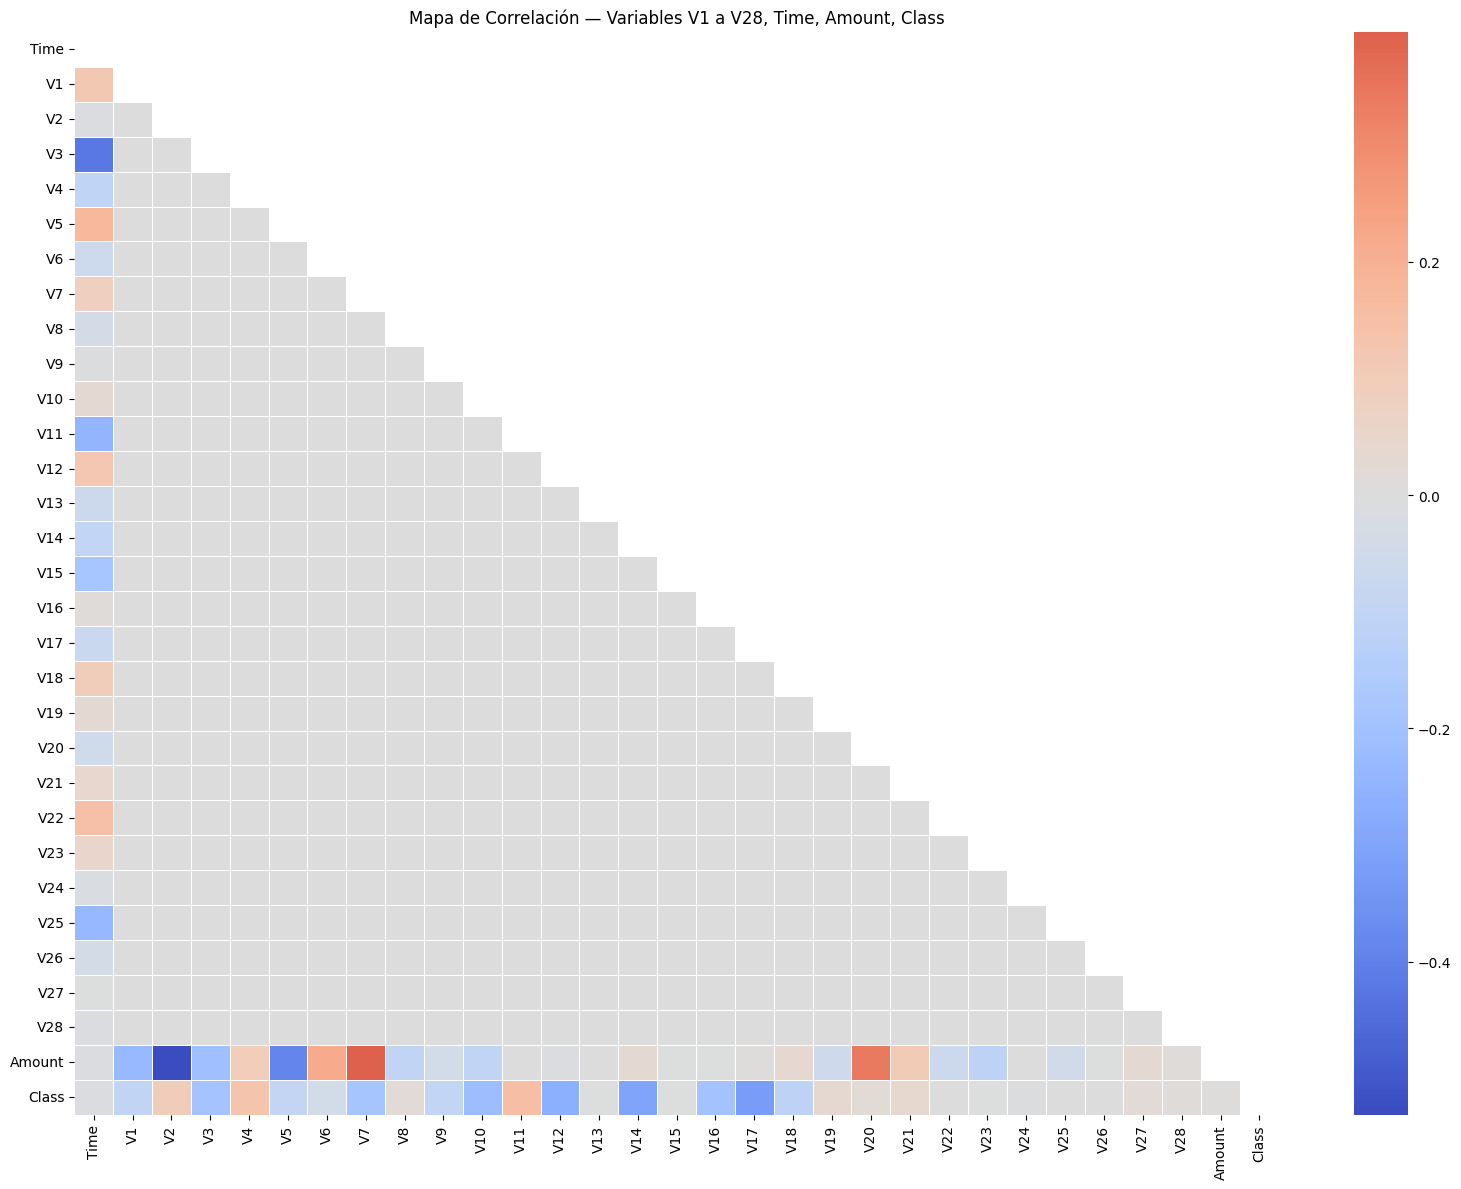


Top 10 correlaciones con 'Class':
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
V18      0.111485
Name: Class, dtype: float64


In [12]:
# ============================================================
# CELDA 7: MAPA DE CORRELACIÓN
# ============================================================
# Calculamos la matriz de correlación completa
plt.figure(figsize=(16, 12))
corr = df.corr()

# Máscara para mostrar solo el triángulo inferior (evita duplicados)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Heatmap con coolwarm: rojo = correlación positiva, azul = negativa
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.5, fmt='.2f')
plt.title('Mapa de Correlación — Variables V1 a V28, Time, Amount, Class')
plt.tight_layout()
plt.show()

# Identificamos las variables con mayor correlación con la clase Fraude
# Esto nos ayuda a entender qué features son más informativos
print("\nTop 10 correlaciones con 'Class':")
print(corr['Class'].abs().sort_values(ascending=False).head(11))

## Fase 3: Preparación de los Datos

En esta fase:
1. Escalamos Time y Amount (las únicas variables no escaladas por PCA)
2. Separamos características (X) y variable objetivo (y)
3. Dividimos en entrenamiento (80%) y prueba (20%) con estratificación
4. Aplicamos SMOTE al conjunto de entrenamiento para balancear las clases

In [13]:
# ============================================================
# CELDA 8: PREPARACIÓN DE DATOS (SCALING + SMOTE + SPLIT)
# ============================================================
# Las componentes PCA (V1-V28) ya vienen escaladas, pero Time y Amount no.
# Aplicamos StandardScaler para normalizarlas (media=0, desviación=1)
scaler = StandardScaler()
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Eliminamos las columnas originales no escaladas
df_clean = df.drop(['Time', 'Amount'], axis=1)

# Separamos características (X) y variable objetivo (y)
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# === TRAIN/TEST SPLIT CON ESTRATIFICACIÓN ===
# Usamos stratify=y para mantener la misma proporción de fraudes
# en ambos conjuntos (esencial con datos desbalanceados)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Fraudes en train: {y_train.sum()} | Fraudes en test: {y_test.sum()}")

# === SMOTE (Synthetic Minority Over-sampling Technique) ===
# SMOTE genera instancias sintéticas de la clase minoritaria (fraude)
# interpolando entre vecinos cercanos. Solo se aplica al entrenamiento
# para evitar data leakage (contaminación del conjunto de prueba)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nDespués de SMOTE — Train shape: {X_train_res.shape}")
print(f"Distribución post-SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

Train: (227845, 30) | Test: (56962, 30)
Fraudes en train: 394 | Fraudes en test: 98

Después de SMOTE — Train shape: (454902, 30)
Distribución post-SMOTE: {0: 227451, 1: 227451}


## Fase 4: Modelado

Entrenamos 4 modelos de clasificación y comparamos su rendimiento:
1. **Regresión Logística** — modelo lineal base
2. **Random Forest** — ensemble de árboles de decisión
3. **XGBoost** — gradient boosting optimizado
4. **Gradient Boosting** — boosting clásico

In [14]:
# ============================================================
# CELDA 9: ENTRENAMIENTO DE MODELOS
# ============================================================
# Diccionario con los 4 modelos a evaluar
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Diccionarios para almacenar resultados y modelos entrenados
resultados = {}
modelos_entrenados = {}

# Iteramos sobre cada modelo, lo entrenamos y evaluamos
for nombre, modelo in modelos.items():
    print(f"\nEntrenando: {nombre}...")
    
    # Entrenamos con los datos balanceados por SMOTE
    modelo.fit(X_train_res, y_train_res)
    
    # Predecimos sobre el conjunto de prueba (NO balanceado — es el mundo real)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Calculamos las 4 métricas principales
    resultados[nombre] = {
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'F1-Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }
    
    # Guardamos el modelo y sus predicciones para la fase de evaluación
    modelos_entrenados[nombre] = {'modelo': modelo, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f"  ROC-AUC: {resultados[nombre]['ROC-AUC']:.4f} | F1: {resultados[nombre]['F1-Score']:.4f}")


Entrenando: Regresión Logística...
  ROC-AUC: 0.9698 | F1: 0.1094

Entrenando: Random Forest...
  ROC-AUC: 0.9841 | F1: 0.8229

Entrenando: XGBoost...
  ROC-AUC: 0.9792 | F1: 0.8018

Entrenando: Gradient Boosting...
  ROC-AUC: 0.9807 | F1: 0.1888


## Fase 5: Evaluación

Comparamos los 4 modelos mediante:
- Tabla comparativa de métricas
- Curvas ROC (área bajo la curva)
- Matriz de confusión del mejor modelo
- Reporte de clasificación detallado

In [15]:
# ============================================================
# CELDA 10: EVALUACIÓN DE MODELOS
# ============================================================
# --- TABLA COMPARATIVA ---
# Convertimos el diccionario en DataFrame para visualización ordenada
df_resultados = pd.DataFrame(resultados).T.round(4)
print("=== COMPARACIÓN DE MODELOS ===")
display(df_resultados.sort_values('ROC-AUC', ascending=False))

# --- CURVAS ROC PARA TODOS LOS MODELOS ---
# Usamos Plotly para gráficas interactivas
fig = go.Figure()
for nombre, data in modelos_entrenados.items():
    fpr, tpr, _ = roc_curve(y_test, data['y_prob'])
    auc = resultados[nombre]['ROC-AUC']
    fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f"{nombre} (AUC={auc:.3f})"))

# Línea diagonal: clasificador aleatorio (AUC=0.5)
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], name='Random',
                          line=dict(dash='dash', color='gray')))
fig.update_layout(title='Curvas ROC — Comparación de Modelos',
                  xaxis_title='False Positive Rate',
                  yaxis_title='True Positive Rate')
fig.show()

# --- MATRIZ DE CONFUSIÓN DEL MEJOR MODELO ---
# Seleccionamos el modelo con mayor ROC-AUC
mejor_nombre = df_resultados['ROC-AUC'].idxmax()
mejor_pred = modelos_entrenados[mejor_nombre]['y_pred']
cm = confusion_matrix(y_test, mejor_pred)

# Visualizamos la matriz de confusión con Plotly
fig_cm = px.imshow(cm, text_auto=True, color_continuous_scale='Blues',
                   labels=dict(x="Predicho", y="Real"),
                   x=['Legítima','Fraude'], y=['Legítima','Fraude'],
                   title=f'Matriz de Confusión — {mejor_nombre}')
fig_cm.show()

# Reporte de clasificación detallado
print(f"\nMejor modelo: {mejor_nombre}")
print(classification_report(y_test, mejor_pred, target_names=['Legítima', 'Fraude']))

=== COMPARACIÓN DE MODELOS ===


,ROC-AUC,F1-Score,Precision,Recall
Random Forest,0.9841,0.8229,0.8404,0.8061
Gradient Boosting,0.9807,0.1888,0.1055,0.8980
XGBoost,0.9792,0.8018,0.7311,0.8878
Regresión Logística,0.9698,0.1094,0.0581,0.9184



Mejor modelo: Random Forest
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.84      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [16]:
# ============================================================
# CELDA 11: GUARDAR EL MEJOR MODELO
# ============================================================
# Guardamos el modelo ganador como archivo .pkl para usarlo
# en la aplicación Flask (app/clasificacion_app/)
os.makedirs('../../app/clasificacion_app/model', exist_ok=True)
joblib.dump(modelos_entrenados[mejor_nombre]['modelo'],
            '../../app/clasificacion_app/model/modelo_fraude.pkl')
print(f"Modelo '{mejor_nombre}' guardado exitosamente en 'app/clasificacion_app/model/modelo_fraude.pkl'.")
print("\n¡Listo! Ahora puedes ejecutar la aplicación Flask con:")
print("  python app/clasificacion_app/app.py")

Modelo 'Random Forest' guardado exitosamente en 'app/clasificacion_app/model/modelo_fraude.pkl'.

¡Listo! Ahora puedes ejecutar la aplicación Flask con:
  python app/clasificacion_app/app.py


## Fase 6: Conclusiones

- El dataset presenta un desbalance severo (0.17% fraudes) que requirió SMOTE para balancear las clases sintéticamente.
- Se entrenaron y compararon 4 modelos de clasificación, evaluando ROC-AUC, F1-Score, Precision y Recall.
- El mejor modelo fue **[COMPLETAR CON RESULTADO REAL]** con ROC-AUC de **[COMPLETAR CON VALOR]**.
- Las variables más influyentes fueron **[COMPLETAR CON VARIABLES DEL ANÁLISIS]**.
- SMOTE permitió mejorar significativamente el Recall de la clase fraude, reduciendo los falsos negativos.
- **Trabajo futuro:** Despliegue en tiempo real con monitoreo de drift, explorar redes neuronales y técnicas de detección de anomalías no supervisadas (Isolation Forest, Autoencoders).